In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Order ID': ['CA-001','CA-002','CA-003','CA-004','CA-005'],
    'Category': ['Furniture','Technology','Office Supplies','Furniture','Technology'],
    'Sub-Category': ['Chairs','Phones','Binders','Tables','Laptops'],
    'Region': ['East','West','Central','South','East'],
    'Sales': [250.5, 890.0, 45.3, 320.8, 1200.0],
    'Profit': [41.9, 267.0, 8.1, -87.0, 360.0],
    'Quantity': [2, 3, 5, 1, 4]
}

df = pd.DataFrame(data)
print(df)

  Order ID         Category Sub-Category   Region   Sales  Profit  Quantity
0   CA-001        Furniture       Chairs     East   250.5    41.9         2
1   CA-002       Technology       Phones     West   890.0   267.0         3
2   CA-003  Office Supplies      Binders  Central    45.3     8.1         5
3   CA-004        Furniture       Tables    South   320.8   -87.0         1
4   CA-005       Technology      Laptops     East  1200.0   360.0         4


In [2]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Data types:\n', df.dtypes)
print('Missing values:\n', df.isnull().sum())

Shape: (5, 7)
Columns: ['Order ID', 'Category', 'Sub-Category', 'Region', 'Sales', 'Profit', 'Quantity']
Data types:
 Order ID         object
Category         object
Sub-Category     object
Region           object
Sales           float64
Profit          float64
Quantity          int64
dtype: object
Missing values:
 Order ID        0
Category        0
Sub-Category    0
Region          0
Sales           0
Profit          0
Quantity        0
dtype: int64


In [3]:
print('Total Sales:', df['Sales'].sum())
print('Total Profit:', df['Profit'].sum())
print('Average Sales:', df['Sales'].mean())
print('\nSales by Category:')
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
print('\nProfit by Region:')
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False))

Total Sales: 2706.6
Total Profit: 590.0
Average Sales: 541.3199999999999

Sales by Category:
Category
Technology         2090.0
Furniture           571.3
Office Supplies      45.3
Name: Sales, dtype: float64

Profit by Region:
Region
East       401.9
West       267.0
Central      8.1
South      -87.0
Name: Profit, dtype: float64


In [4]:
print('High Sales (above 500):')
print(df[df['Sales'] > 500])
print('\nFurniture only:')
print(df[df['Category'] == 'Furniture'])

High Sales (above 500):
  Order ID    Category Sub-Category Region   Sales  Profit  Quantity
1   CA-002  Technology       Phones   West   890.0   267.0         3
4   CA-005  Technology      Laptops   East  1200.0   360.0         4

Furniture only:
  Order ID   Category Sub-Category Region  Sales  Profit  Quantity
0   CA-001  Furniture       Chairs   East  250.5    41.9         2
3   CA-004  Furniture       Tables  South  320.8   -87.0         1


In [5]:
print('Top 3 Sales:')
print(df.sort_values('Sales', ascending=False).head(3))

Top 3 Sales:
  Order ID    Category Sub-Category Region   Sales  Profit  Quantity
4   CA-005  Technology      Laptops   East  1200.0   360.0         4
1   CA-002  Technology       Phones   West   890.0   267.0         3
3   CA-004   Furniture       Tables  South   320.8   -87.0         1


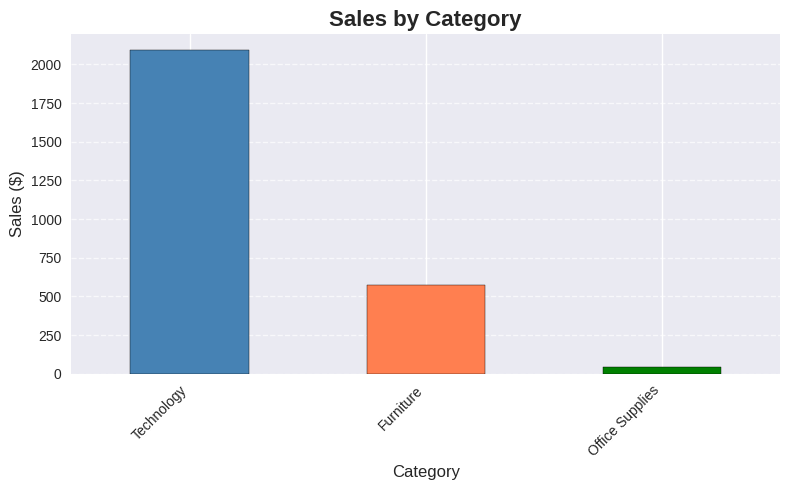

In [6]:
plt.style.use('seaborn-v0_8')
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(
    kind='bar',
    color=['steelblue','coral','green'],
    figsize=(8,5),
    edgecolor='black'
)
plt.title('Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

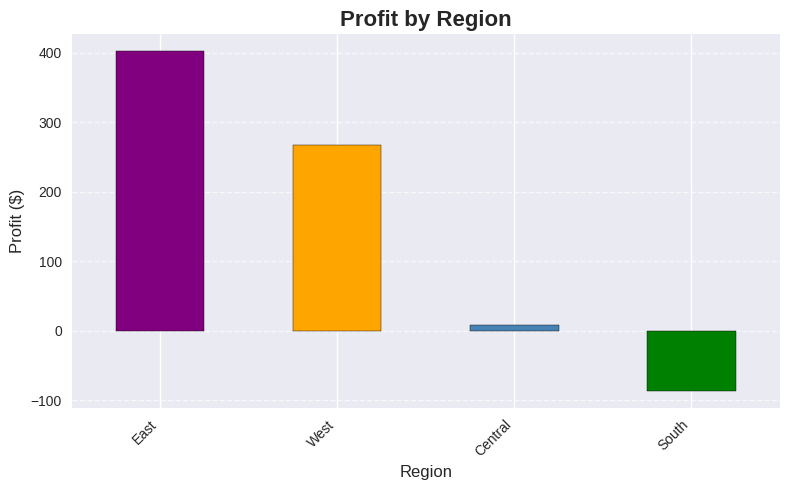

In [7]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False).plot(
    kind='bar',
    color=['purple','orange','steelblue','green'],
    figsize=(8,5),
    edgecolor='black'
)
plt.title('Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

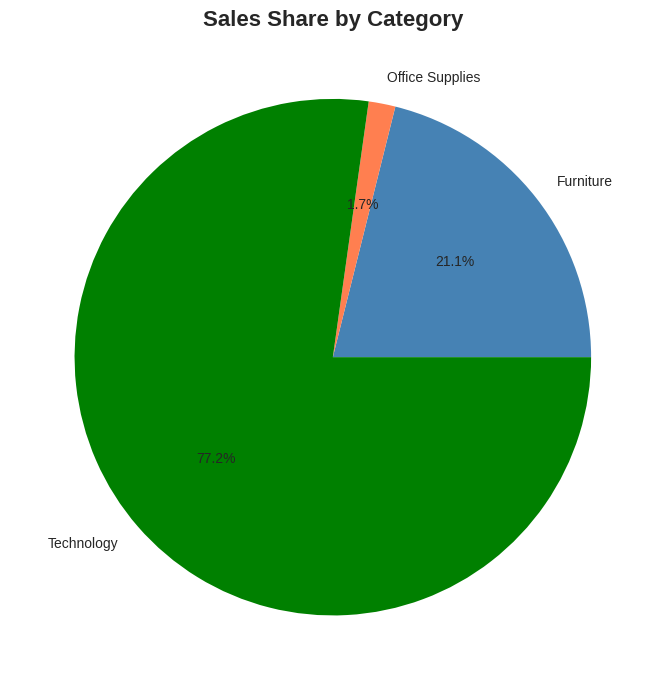

In [8]:
df.groupby('Category')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    colors=['steelblue','coral','green']
)
plt.title('Sales Share by Category', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

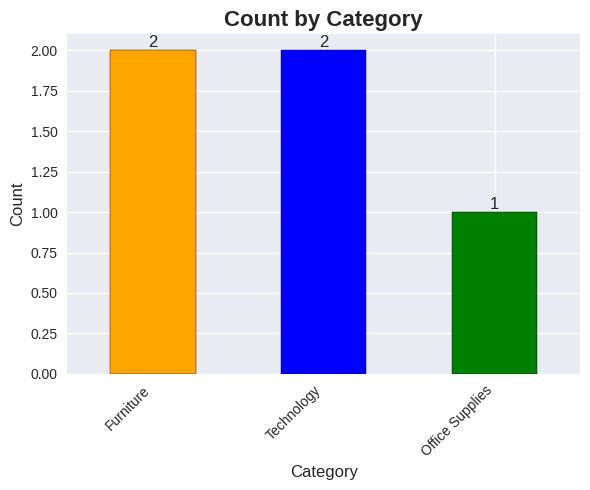

In [9]:
ax = df['Category'].value_counts().plot(
    kind='bar',
    color=['orange','blue','green'],
    figsize=(6,5),
    edgecolor='black'
)
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        xy=(p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title('Count by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()